<a href="https://colab.research.google.com/github/Krishna-matic/python_practice/blob/main/Classification_Deep_learning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns

In [5]:
df = pd.read_csv("/content/drive/MyDrive/DataSetForpython/brain_stroke_new.csv")

In [6]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5140 entries, 0 to 5139
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5140 non-null   object 
 1   age                5140 non-null   float64
 2   hypertension       5140 non-null   int64  
 3   heart_disease      5140 non-null   int64  
 4   ever_married       5140 non-null   object 
 5   work_type          5140 non-null   object 
 6   Residence_type     5140 non-null   object 
 7   avg_glucose_level  5140 non-null   float64
 8   bmi                5121 non-null   float64
 9   smoking_status     5140 non-null   object 
 10  stroke             5140 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 441.8+ KB


In [9]:
df.shape

(5140, 11)

In [10]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [11]:
# Check null values
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,19
smoking_status,0


In [12]:
# Fill missing BMI values with the median
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

In [13]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0
smoking_status,0


In [14]:
# One-Hot Encode categorical columns
df = pd.get_dummies(
    df,
    columns=['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'],
    drop_first=True
)

In [15]:
df.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,ever_married_Yes,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,True,True,True,False,False,True,True,False,False
1,80.0,0,1,105.92,32.5,1,True,True,True,False,False,False,False,True,False
2,49.0,0,0,171.23,34.4,1,False,True,True,False,False,True,False,False,True
3,79.0,1,0,174.12,24.0,1,False,True,False,True,False,False,False,True,False
4,81.0,0,0,186.21,29.0,1,True,True,True,False,False,True,True,False,False


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5140 entries, 0 to 5139
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             5140 non-null   float64
 1   hypertension                    5140 non-null   int64  
 2   heart_disease                   5140 non-null   int64  
 3   avg_glucose_level               5140 non-null   float64
 4   bmi                             5140 non-null   float64
 5   stroke                          5140 non-null   int64  
 6   gender_Male                     5140 non-null   bool   
 7   ever_married_Yes                5140 non-null   bool   
 8   work_type_Private               5140 non-null   bool   
 9   work_type_Self-employed         5140 non-null   bool   
 10  work_type_children              5140 non-null   bool   
 11  Residence_type_Urban            5140 non-null   bool   
 12  smoking_status_formerly smoked  51

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
# Features
X = df.drop('stroke', axis=1)

# Target
y = df['stroke']

In [20]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (5140, 14)
Shape of y: (5140,)


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (4112, 14)
X_test : (1028, 14)
y_train: (4112,)
y_test : (1028,)


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
print(type(X_train_scaled))
print(X_train_scaled.shape)

print(type(X_test_scaled))
print(X_test_scaled.shape)

<class 'numpy.ndarray'>
(4112, 14)
<class 'numpy.ndarray'>
(1028, 14)


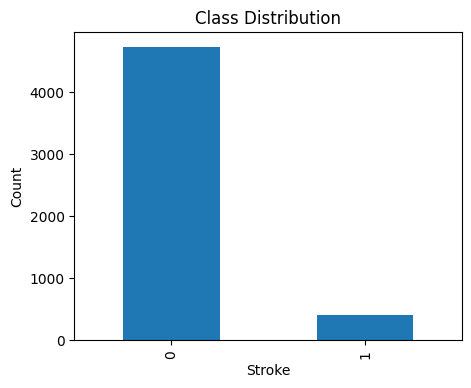

In [25]:


plt.figure(figsize=(5,4))
y.value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Stroke")
plt.ylabel("Count")
plt.show()

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [27]:
y_pred = rf.predict(X_test)

y_prob = rf.predict_proba(X_test)[:, 1]

In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.9328793774319066
Precision: 0.7727272727272727
Recall   : 0.20987654320987653
F1 Score : 0.3300970873786408
ROC AUC  : 0.9096301510944241

Classification Report

              precision    recall  f1-score   support

           0       0.94      0.99      0.96       947
           1       0.77      0.21      0.33        81

    accuracy                           0.93      1028
   macro avg       0.85      0.60      0.65      1028
weighted avg       0.92      0.93      0.91      1028



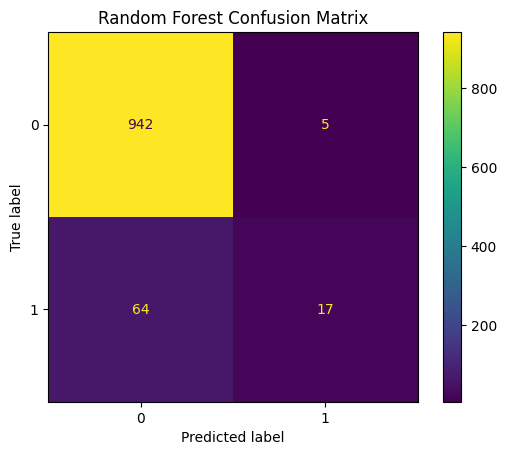

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title("Random Forest Confusion Matrix")
plt.show()

In [31]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    max_iter=1000
)

lr.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [32]:
y_pred_lr = lr.predict(X_test_scaled)

y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_lr))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_lr))

Accuracy : 0.7461089494163424
Precision: 0.19798657718120805
Recall   : 0.7283950617283951
F1 Score : 0.3113456464379947
ROC AUC  : 0.8223760543366315

Classification Report

              precision    recall  f1-score   support

           0       0.97      0.75      0.84       947
           1       0.20      0.73      0.31        81

    accuracy                           0.75      1028
   macro avg       0.58      0.74      0.58      1028
weighted avg       0.91      0.75      0.80      1028



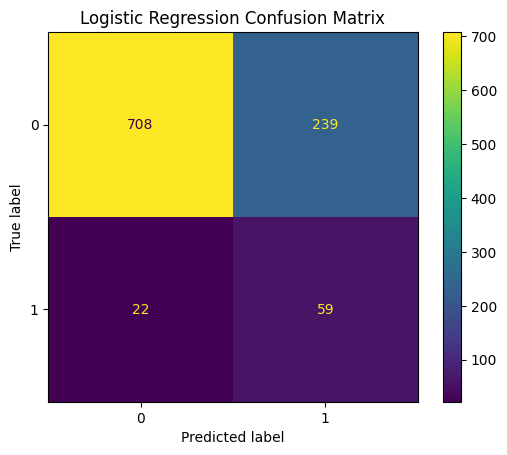

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay


ConfusionMatrixDisplay.from_estimator(lr, X_test_scaled, y_test)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [35]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [36]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),


    Dense(32, activation='relu'),


    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [40]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [38]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))

print(class_weight_dict)

{np.int64(0): np.float64(0.5430533544638141), np.int64(1): np.float64(6.306748466257669)}


In [41]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7175 - loss: 0.6069 - val_accuracy: 0.6731 - val_loss: 0.5582
Epoch 2/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7078 - loss: 0.4775 - val_accuracy: 0.7424 - val_loss: 0.4682
Epoch 3/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7400 - loss: 0.4450 - val_accuracy: 0.7643 - val_loss: 0.4398
Epoch 4/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7525 - loss: 0.4287 - val_accuracy: 0.7254 - val_loss: 0.4957
Epoch 5/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7513 - loss: 0.4175 - val_accuracy: 0.7764 - val_loss: 0.4094
Epoch 6/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7644 - loss: 0.4057 - val_accuracy: 0.7691 - val_loss: 0.4186
Epoch 7/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7635 - loss: 0.3970 - val_accuracy: 0.7521 - val_loss: 0.4526
Epoch 8/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7738 - loss: 0.3870 - val_accu

In [42]:
loss, accuracy = model.evaluate(X_test_scaled, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7870 - loss: 0.3761
Test Loss: 0.37609773874282837
Test Accuracy: 0.7869649529457092


In [43]:
y_prob_dl = model.predict(X_test_scaled)

y_pred_dl = (y_prob_dl > 0.5).astype(int)

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [44]:
y_pred_dl = y_pred_dl.flatten()
y_prob_dl = y_prob_dl.flatten()

In [45]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_dl))
print("Precision:", precision_score(y_test, y_pred_dl))
print("Recall   :", recall_score(y_test, y_pred_dl))
print("F1 Score :", f1_score(y_test, y_pred_dl))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_dl))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_dl))

Accuracy : 0.7869649805447471
Precision: 0.20512820512820512
Recall   : 0.5925925925925926
F1 Score : 0.3047619047619048
ROC AUC  : 0.8208638064322682

Classification Report

              precision    recall  f1-score   support

           0       0.96      0.80      0.87       947
           1       0.21      0.59      0.30        81

    accuracy                           0.79      1028
   macro avg       0.58      0.70      0.59      1028
weighted avg       0.90      0.79      0.83      1028

